In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SIZE = 16
plt.rcParams["font.family"] = "serif"
plt.rc('font',   size = SIZE)       # controls default text sizes
plt.rc('axes',   labelsize = SIZE)  # fontsize of the x and y labels
plt.rc('xtick',  labelsize = SIZE)  # fontsize of the tick labels
plt.rc('ytick',  labelsize = SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize  = SIZE)  # legend fontsize
plt.rc('figure', titlesize = SIZE)  # fontsize of the figure title

In [4]:
def find_start_row(file_path):
    with open(file_path, "r") as f:
        for i, line in enumerate(f):
            if line.startswith("OPAL"):
                print(f"Data starts at line: {i + 2}")
                return i + 2
    raise ValueError("No line starting with 'OPAL' found.")

In [119]:
file_path = '/Users/michalis/Work/git_projects/regression-tests-x/RegressionTests/TWCavity/' 

opal_file = file_path + 'OPAL/' + 'P3MSwissFEL.stat'
# opal_file = file_path + 'reference/' + 'AWAGun-RFOnly-opal.stat'
opal = pd.read_csv(opal_file, sep = r"\s+", 
                   skiprows = find_start_row(opal_file), 
                   header = None)

opalx_file = file_path + 'TWCavity.stat'
opalx = pd.read_csv(opalx_file, sep = r"\s+", 
                    skiprows = find_start_row(opalx_file), 
                    header = None)

Data starts at line: 303
Data starts at line: 309


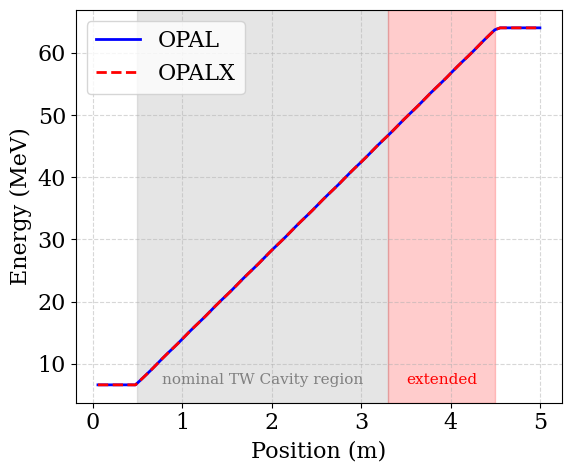

In [ ]:
f, ax = plt.subplots(figsize = (6, 5))

ax.plot(opal[1], opal[4], color = 'blue', lw = 2, ls = '-',label = 'OPAL')
ax.plot(opalx[1], opalx[4], color = 'red', lw = 2, ls = '--',label = 'OPALX')

ax.axvspan(0.5, 3.3, color='grey', alpha=0.2)
ax.axvspan(3.3, 4.5, color='red', alpha=0.2)

ax.annotate('Nominal TW Cavity region',
            xy=(1.9, 6.5), xytext=(1.9, 6.7),
            color='grey', ha='center', fontsize=11)

ax.annotate('extended',
            xy=(3.9, 6.5), xytext=(3.9, 6.7),
            color='red', ha='center', fontsize=11)

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_xlim(1.1, 1.2)
# ax.set_ylim(15.5, 17)
# ax.set_ylim(6, 6.8)
ax.set_ylabel('Energy (MeV)')
ax.set_xlabel('Position (m)')

f.tight_layout()
f.savefig('SwissFEL_energy_comparison.png', dpi = 300)


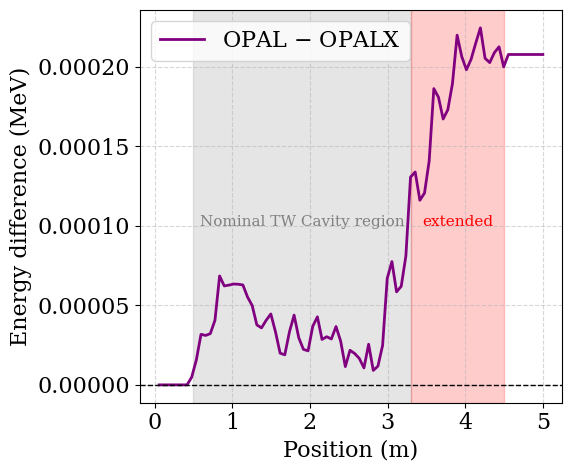

In [155]:
f, ax = plt.subplots(figsize = (6, 5))

diff = abs(opal[4] - opalx[4])

ax.plot(opal[1], diff, color = 'purple', lw = 2, ls = '-', label = r'OPAL $-$ OPALX')
ax.axhline(0, color = 'k', ls = '--', lw = 1)

# ax.axvspan(0.5, 3.3, color = 'grey', alpha = 0.2)
# ax.axvspan(3.3, 4.5, color = 'red', alpha = 0.2)
# ax.annotate('TW Cavity region', xy = (2, 0.0001), xytext = (2, 0.0001), color = 'grey', ha = 'center', fontsize = 12)
# ax.annotate('effective length?', xy = (3.9, 0.0001), xytext = (3.9, 0.0001), color = 'r', ha = 'center', fontsize = 12)

ax.axvspan(0.5, 3.3, color='grey', alpha=0.2)
ax.axvspan(3.3, 4.5, color='red', alpha=0.2)

ax.annotate('Nominal TW Cavity region',
            xy=(1.9, 0.0001), xytext=(1.9, 0.0001),
            color='grey', ha='center', fontsize=11)

ax.annotate('extended',
            xy=(3.9, 0.0001), xytext=(3.9, 0.0001),
            color='red', ha='center', fontsize=11)

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_xlim(0, 0.45)
# ax.set_ylim(-0.05, 0.055)
ax.set_xlabel('Position (m)')
ax.set_ylabel('Energy difference (MeV)')

f.tight_layout()
f.savefig('SwissFEL_energy_difference.png', dpi = 300)

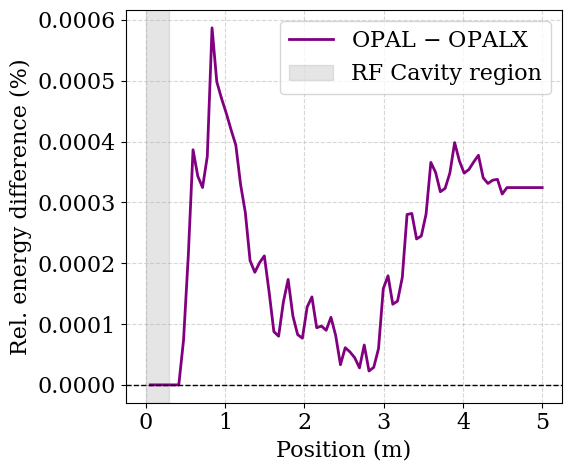

In [ ]:
f, ax = plt.subplots(figsize = (6, 5))

diff = abs(opal[4] - opalx[4]) * 100 / opal[4]

ax.plot(opal[1], diff, color = 'purple', lw = 2, ls = '-', label = r'OPAL $-$ OPALX')
ax.axhline(0, color = 'k', ls = '--', lw = 1)

ax.axvspan(0, 0.2927, color='grey', alpha = 0.2, label = 'RF Cavity region')

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

# ax.set_xlim(0, 0.45)
# ax.set_ylim(-0.05, 0.055)
ax.set_xlabel('Position (m)')
ax.set_ylabel('Rel. energy difference (%)')

f.tight_layout()
f.savefig('SwissFEL_energy_difference_percent.png', dpi = 300)

(0.0, 0.8)

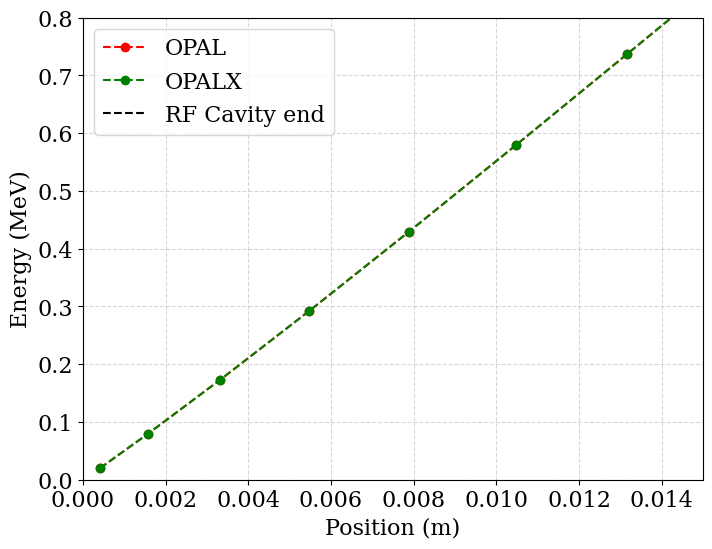

In [7]:
f, ax = plt.subplots(figsize = (8, 6))

ax.plot(opal[1], opal[4], color = 'red', marker = 'o', ls = '--',label = 'OPAL')
ax.plot(opalx[1], opalx[4], color = 'green', marker = 'o', ls = '--',label = 'OPALX')

ax.axvline(x = 0.2927, color = 'k', linestyle = '--', label = 'RF Cavity end')

ax.legend()
ax.grid(True, ls = '--', alpha = 0.5)

ax.set_ylabel('Energy (MeV)')
ax.set_xlabel('Position (m)')
ax.set_xlim(0, 0.015)
ax.set_ylim(0, 0.8)
# ax.set_ylim(6.27, 6.28)


2.4517896881551726